In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/races.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_results.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/drivers.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructors.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/lap_times.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/status.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/driver_standings.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/seasons.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/pit_stops.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/sprint_results.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_standings.csv
/kaggle/input/datasets/rohanrao/formula

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = "/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020"

circuits = pd.read_csv(f"{BASE_PATH}/circuits.csv", na_values="\\N")
constructors = pd.read_csv(f"{BASE_PATH}/constructors.csv", na_values="\\N")
constructor_results = pd.read_csv(f"{BASE_PATH}/constructor_results.csv", na_values="\\N")
constructor_standings = pd.read_csv(f"{BASE_PATH}/constructor_standings.csv", na_values="\\N")
drivers = pd.read_csv(f"{BASE_PATH}/drivers.csv", na_values="\\N")
driver_standings = pd.read_csv(f"{BASE_PATH}/driver_standings.csv", na_values="\\N")
races = pd.read_csv(f"{BASE_PATH}/races.csv", na_values="\\N")
results = pd.read_csv(f"{BASE_PATH}/results.csv", na_values="\\N")
qualifying = pd.read_csv(f"{BASE_PATH}/qualifying.csv", na_values="\\N")
lap_times = pd.read_csv(f"{BASE_PATH}/lap_times.csv", na_values="\\N")
pit_stops = pd.read_csv(f"{BASE_PATH}/pit_stops.csv", na_values="\\N")
sprint_results = pd.read_csv(f"{BASE_PATH}/sprint_results.csv", na_values="\\N")
seasons = pd.read_csv(f"{BASE_PATH}/seasons.csv", na_values="\\N")
status = pd.read_csv(f"{BASE_PATH}/status.csv", na_values="\\N")

pd.set_option("display.max_columns", None)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [3]:
tables = {
    "circuits": circuits,
    "constructors": constructors,
    "constructor_results": constructor_results,
    "constructor_standings": constructor_standings,
    "drivers": drivers,
    "driver_standings": driver_standings,
    "races": races,
    "results": results,
    "qualifying": qualifying,
    "lap_times": lap_times,
    "pit_stops": pit_stops,
    "sprint_results": sprint_results,
    "seasons": seasons,
    "status": status
}

overview = []

for name, df in tables.items():
    overview.append({
        "table": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_values": df.isna().sum().sum(),
        "duplicate_rows": df.duplicated().sum()
    })

overview_df = pd.DataFrame(overview)
overview_df

,table,rows,columns,missing_values,duplicate_rows
0,circuits,77,9,0,0
1,constructors,212,5,0,0
2,constructor_results,12625,5,12608,0
3,constructor_standings,13391,7,0,0
4,drivers,861,9,1559,0
5,driver_standings,34863,7,0,0
6,races,1125,18,11349,0
7,results,26759,18,122887,0
8,qualifying,10494,9,11668,0
9,lap_times,589081,6,0,0


In [4]:
for name, df in tables.items():
    missing = df.isna().sum()
    missing = missing[missing > 0]

    print(f"\n{name}")
    if len(missing) == 0:
        print("No missing values")
    else:
        print(missing.sort_values(ascending=False))


circuits
No missing values

constructors
No missing values

constructor_results
status    12608
dtype: int64

constructor_standings
No missing values

drivers
number    802
code      757
dtype: int64

driver_standings
No missing values

races
sprint_time    1110
sprint_date    1107
fp3_time       1072
quali_time     1057
fp2_time       1057
fp1_time       1057
fp3_date       1053
fp2_date       1035
fp1_date       1035
quali_date     1035
time            731
dtype: int64

results
milliseconds       19079
time               19079
fastestLapTime     18507
fastestLap         18507
fastestLapSpeed    18507
rank               18249
position           10953
number                 6
dtype: int64

qualifying
q3    6865
q2    4647
q1     156
dtype: int64

lap_times
No missing values

pit_stops
No missing values

sprint_results
time              20
milliseconds      20
position          15
fastestLap         9
fastestLapTime     9
dtype: int64

seasons
No missing values

status
No missing value

In [5]:
driver_race_counts = (
    results
    .groupby(["raceId", "driverId"])
    .size()
    .reset_index(name="count")
)

duplicate_driver_races = driver_race_counts[
    driver_race_counts["count"] > 1
]

print("Number of duplicated driver-race combinations:",
      len(duplicate_driver_races))

duplicate_driver_races.head(20)

Number of duplicated driver-race combinations: 85


,raceId,driverId,count
13659,540,229,2
17821,717,373,2
18222,733,465,2
18445,742,475,2
18532,745,418,2
18553,746,475,2
18982,766,541,2
19080,770,479,2
19170,774,566,2
19210,776,581,2


In [6]:
duplicate_rows_detail = results.merge(
    duplicate_driver_races[["raceId", "driverId"]],
    on=["raceId", "driverId"],
    how="inner"
).sort_values(["raceId", "driverId"])

duplicate_rows_detail[
    ["raceId", "driverId", "constructorId",
     "grid", "positionOrder", "points"]
].head(30)

,raceId,driverId,constructorId,grid,positionOrder,points
0,540,229,54,0,26,0.0
1,540,229,57,0,29,0.0
2,717,373,172,1,7,0.0
175,717,373,172,1,12,0.0
3,733,465,172,0,22,0.0
4,733,465,97,0,25,0.0
5,742,475,102,20,19,0.0
6,742,475,172,5,21,0.0
7,745,418,172,11,17,0.0
174,745,418,172,15,11,0.0


In [7]:
print("Earliest season:", races["year"].min())
print("Latest season:", races["year"].max())
print("Number of seasons:", races["year"].nunique())

Earliest season: 1950
Latest season: 2024
Number of seasons: 75


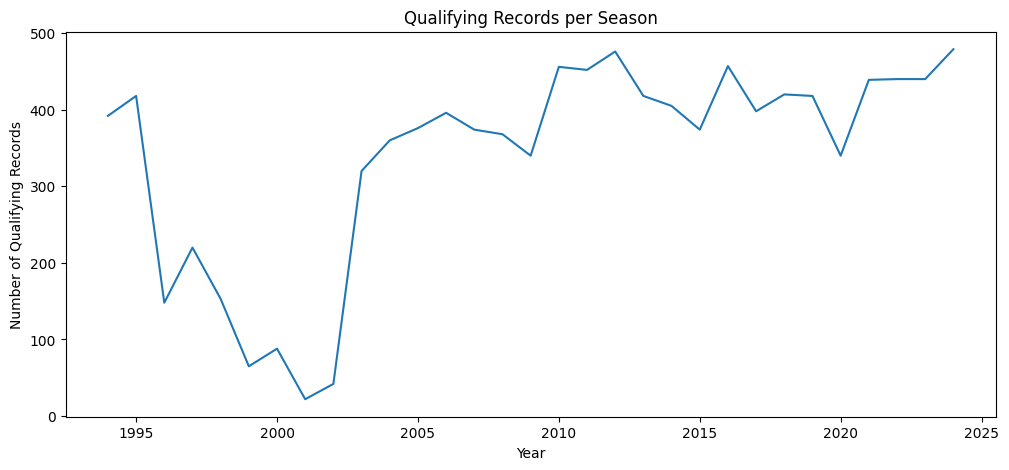

In [8]:
qualifying_by_year = (
    qualifying
    .merge(races[["raceId", "year"]], on="raceId", how="left")
    .groupby("year")
    .size()
    .reset_index(name="qualifying_rows")
)

qualifying_by_year.plot(
    x="year",
    y="qualifying_rows",
    figsize=(12, 5),
    legend=False
)

plt.title("Qualifying Records per Season")
plt.xlabel("Year")
plt.ylabel("Number of Qualifying Records")
plt.show()

In [9]:
duplicate_details = results.merge(
    duplicate_driver_races[["raceId", "driverId"]],
    on=["raceId", "driverId"],
    how="inner"
).sort_values(["raceId", "driverId"])

duplicate_details[
    [
        "raceId",
        "driverId",
        "constructorId",
        "number",
        "grid",
        "positionOrder",
        "points",
        "statusId"
    ]
].head(30)

,raceId,driverId,constructorId,number,grid,positionOrder,points,statusId
0,540,229,54,10.0,0,26,0.0,81
1,540,229,57,23.0,0,29,0.0,97
2,717,373,172,1.0,1,7,0.0,60
175,717,373,172,2.0,1,12,0.0,98
3,733,465,172,48.0,0,22,0.0,54
4,733,465,97,50.0,0,25,0.0,54
5,742,475,102,26.0,20,19,0.0,2
6,742,475,172,28.0,5,21,0.0,23
7,745,418,172,22.0,11,17,0.0,6
174,745,418,172,21.0,15,11,0.0,18


In [10]:
duplicate_details_named = (
    duplicate_details
    .merge(
        races[["raceId", "year", "name"]],
        on="raceId",
        how="left"
    )
    .merge(
        drivers[["driverId", "forename", "surname"]],
        on="driverId",
        how="left"
    )
)

duplicate_details_named[
    [
        "year",
        "name",
        "forename",
        "surname",
        "raceId",
        "driverId",
        "grid",
        "positionOrder",
        "points"
    ]
].head(30)

,year,name,forename,surname,raceId,driverId,grid,positionOrder,points
0,1978,Italian Grand Prix,Harald,Ertl,540,229,0,26,0.0
1,1978,Italian Grand Prix,Harald,Ertl,540,229,0,29,0.0
2,1964,United States Grand Prix,Jim,Clark,717,373,1,7,0.0
3,1964,United States Grand Prix,Jim,Clark,717,373,1,12,0.0
4,1962,British Grand Prix,Keith,Greene,733,465,0,22,0.0
5,1962,British Grand Prix,Keith,Greene,733,465,0,25,0.0
6,1961,British Grand Prix,Stirling,Moss,742,475,20,19,0.0
7,1961,British Grand Prix,Stirling,Moss,742,475,5,21,0.0
8,1961,United States Grand Prix,Masten,Gregory,745,418,11,17,0.0
9,1961,United States Grand Prix,Masten,Gregory,745,418,15,11,0.0


In [11]:
duplicate_years = (
    duplicate_details_named
    .groupby("year")[["raceId", "driverId"]]
    .apply(lambda x: len(x.drop_duplicates()))
)

duplicate_years

year
1950     4
1951     4
1952     3
1953    14
1954    16
1955    15
1956    12
1957     8
1958     3
1960     1
1961     2
1962     1
1964     1
1978     1
dtype: int64

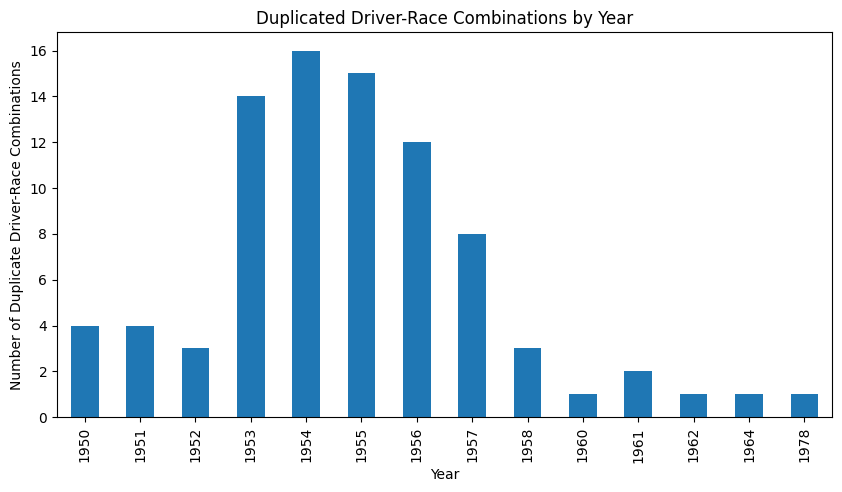

In [12]:
duplicate_years.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Duplicated Driver-Race Combinations by Year")
plt.xlabel("Year")
plt.ylabel("Number of Duplicate Driver-Race Combinations")
plt.show()

In [13]:
print("Earliest season:", races["year"].min())
print("Latest season:", races["year"].max())
print("Number of seasons:", races["year"].nunique())

Earliest season: 1950
Latest season: 2024
Number of seasons: 75


In [14]:
results_preview = results.copy()

results_preview["podium"] = (
    results_preview["positionOrder"] <= 3
).astype(int)

print(results_preview["podium"].value_counts())
print()
print(results_preview["podium"].value_counts(normalize=True) * 100)

podium
0    23362
1     3397
Name: count, dtype: int64

podium
0    87.305206
1    12.694794
Name: proportion, dtype: float64


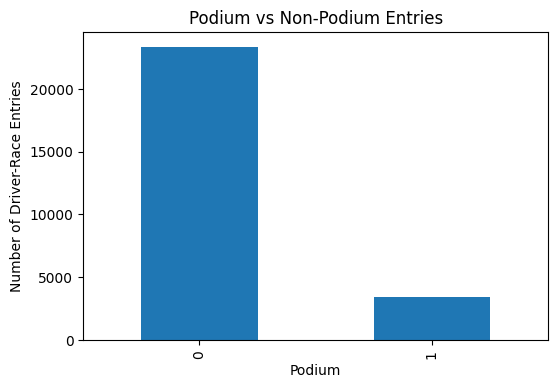

In [15]:
results_preview["podium"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Podium vs Non-Podium Entries")
plt.xlabel("Podium")
plt.ylabel("Number of Driver-Race Entries")
plt.show()

In [16]:
qualifying_with_year = qualifying.merge(
    races[["raceId", "year"]],
    on="raceId",
    how="left"
)

qualifying_coverage = (
    qualifying_with_year
    .groupby("year")
    .size()
    .reset_index(name="qualifying_rows")
)

qualifying_coverage.head()

,year,qualifying_rows
0,1994,392
1,1995,418
2,1996,148
3,1997,220
4,1998,153


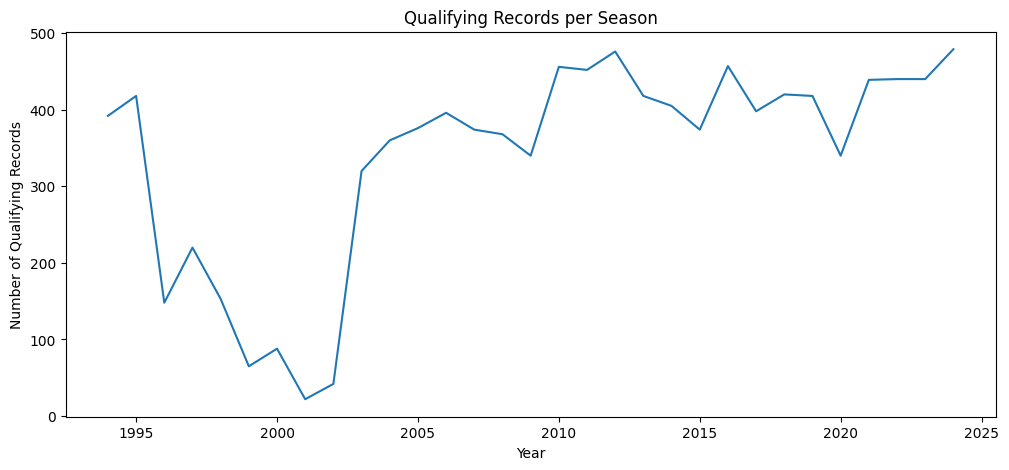

In [17]:
qualifying_coverage.plot(
    x="year",
    y="qualifying_rows",
    figsize=(12, 5),
    legend=False
)

plt.title("Qualifying Records per Season")
plt.xlabel("Year")
plt.ylabel("Number of Qualifying Records")
plt.show()